# Data Cleaning & Loading in Database

In [1]:
# importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the dataset


#dim_customers
df_1 = pd.read_csv(r"X:\00 Portfolio Projects\00 New Projects\For Resume\Python + Power BI Bank Dashboard\C8_Input_Files\Project Files\working_data\raw_data\dim_customers.csv")

#fact_spends
df_2 = pd.read_csv(r"X:\00 Portfolio Projects\00 New Projects\For Resume\Python + Power BI Bank Dashboard\C8_Input_Files\Project Files\working_data\raw_data\fact_spends.csv")

### Data Cleaning dim_customers

In [3]:
# overview of the data

df_1.head(10)

,customer_id,age,city,occupation,gender,marital status,avg_income
0,ATQCUS1825,52,Bengaluru,Salaried IT Employees,Male,Married,73523
1,ATQCUS0809,28,Hyderabad,Salaried Other Employees,Male,Married,Rs.39922
2,ATQCUS0663,32,Chennai,Salaried Other Employees,Male,Married,Rs.37702.00
3,ATQCUS0452,29,Delhi NCR,Government Employees,female,Married,54090.00
4,ATQCUS3350,23,Bengaluru,Freelancers,Male,Single,28376
5,ATQCUS3256,22,Delhi NCR,Salaried IT Employees,Male,NaN,Rs.46586
6,ATQCUS3608,27,Chennai,Freelancers,Male,Single,34966
7,ATQCUS0611,31,Chennai,Salaried IT Employees,Male,Married,59078
8,ATQCUS3856,23,Bengaluru,Salaried Other Employees,Female,Single,Rs.30424.00
9,ATQCUS2640,45,Delhi NCR,Salaried IT Employees,Female,NaN,67450


In [4]:
df_1.shape

(4015, 7)

In [5]:
# Checking for duplicates

df_1.duplicated().sum()

np.int64(15)

**There are 15 duplicates in this dataset**

In [6]:
# Removing duplicates

df_1.drop_duplicates(inplace=True)

In [7]:
df_1.shape

(4000, 7)

**Removed the duplicates**

In [8]:
# overview of dataset information

df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     4000 non-null   object
 1   age             4000 non-null   int64 
 2   city            4000 non-null   object
 3   occupation      4000 non-null   object
 4   gender          4000 non-null   object
 5   marital status  3605 non-null   object
 6   avg_income      3980 non-null   object
dtypes: int64(1), object(6)
memory usage: 250.0+ KB


In [9]:
# Checking the value counts for the categorical columns

categorical_cols = [
    col for col in df_1.select_dtypes(include=["object", "category"]).columns
    if not col.endswith("_id")
]

for col in categorical_cols:
    print(f"\n\nValue counts for {col}:")
    print(df_1[col].value_counts(dropna=False))



Value counts for city:
city
Mumbai             1032
Chennai             800
Bengaluru           727
Delhi NCR           719
Hyderabad           568
   Mumbai            46
   Chennai           34
   Delhi NCR         25
   Hyderabad         25
   Bengaluru         24
Name: count, dtype: int64


Value counts for occupation:
occupation
Salaried IT Employees             1258
Salaried Other Employees           861
Freelancers                        756
Business Owners                    608
Government Employees               394
   Salaried IT Employees            36
   Salaried Other Employees         32
   Freelancers                      28
   Business Owners                  22
   Government Employees              5
Name: count, dtype: int64


Value counts for gender:
gender
Male      2303
Female    1244
male       163
M          145
female      77
F           68
Name: count, dtype: int64


Value counts for marital status:
marital status
Married    2826
Single      779
NaN         39

* **There are null values in both marital status and avg_income column.**
* **The values in city, occupation, gender and avg_income column have data irregularity. Such as whitespaces, irregular prefix and suffix.**

In [10]:
# Standardizing column name of marital status

df_1.rename(columns = {"marital status" : "marital_status"}, inplace=True)
df_1.columns

Index(['customer_id', 'age', 'city', 'occupation', 'gender', 'marital_status',
       'avg_income'],
      dtype='object')

In [11]:
# Removing leading and trailing whitespaces in city and occupation column

cols = ["city", "occupation"]
df_1[cols] = df_1[cols].apply(lambda x: x.str.strip())

In [12]:
chk_cols = ["city", "occupation"]

for col in chk_cols:
    print(f"\n\nValue counts for {col}:")
    print(df_1[col].value_counts(dropna=False))



Value counts for city:
city
Mumbai       1078
Chennai       834
Bengaluru     751
Delhi NCR     744
Hyderabad     593
Name: count, dtype: int64


Value counts for occupation:
occupation
Salaried IT Employees       1294
Salaried Other Employees     893
Freelancers                  784
Business Owners              630
Government Employees         399
Name: count, dtype: int64


**Removed leading and trailing whitespaces from city and occupation.**

In [13]:
df_1.tail(10)

,customer_id,age,city,occupation,gender,marital_status,avg_income
3990,ATQCUS2871,44,Chennai,Freelancers,Female,Married,Rs.37965
3991,ATQCUS0876,28,Hyderabad,Government Employees,Male,Married,Rs.50788
3992,ATQCUS3498,34,Mumbai,Government Employees,Male,Single,Rs.52596.00
3993,ATQCUS3114,53,Chennai,Government Employees,Female,Married,Rs.61997
3994,ATQCUS3656,43,Mumbai,Salaried Other Employees,Male,Single,Rs.42825
3995,ATQCUS3035,52,Delhi NCR,Business Owners,Female,Married,72805.00
3996,ATQCUS2585,39,Mumbai,Salaried Other Employees,Female,Married,41343
3997,ATQCUS1229,42,Bengaluru,Salaried IT Employees,Male,Married,65948
3998,ATQCUS0581,28,Bengaluru,Government Employees,Male,Married,52589.00
3999,ATQCUS3477,26,Mumbai,Business Owners,Male,Single,Rs.73541.00


In [14]:
# Standardizing values in gender column

gender_map = {
    "M" : "Male",
    "Male" : "Male",
    "male" : "Male",
    "F" : "Female",
    "Female" : "Female",
    "female" : "Female"
}

df_1["gender"] = df_1["gender"].replace(gender_map)
df_1["gender"].value_counts()

gender
Male      2611
Female    1389
Name: count, dtype: int64

**Standardized the data in gender column.**

In [15]:
# Filling null values in marital_status column as "Unknown"

df_1["marital_status"] = df_1["marital_status"].fillna("Unknown")
df_1["marital_status"].isnull().sum()

np.int64(0)

In [16]:
df_1["marital_status"].value_counts()

marital_status
Married    2826
Single      779
Unknown     395
Name: count, dtype: int64

**Removed nulls in marital status column.**

In [17]:
# Removing "Rs." prefix and ".00" suffix from avg_income column

df_1["avg_income"] = (
    df_1["avg_income"]
        .str.replace("Rs.", "", regex=False)
        .str.replace(".00", "", regex=False)
)

df_1.tail(10)

,customer_id,age,city,occupation,gender,marital_status,avg_income
3990,ATQCUS2871,44,Chennai,Freelancers,Female,Married,37965
3991,ATQCUS0876,28,Hyderabad,Government Employees,Male,Married,50788
3992,ATQCUS3498,34,Mumbai,Government Employees,Male,Single,52596
3993,ATQCUS3114,53,Chennai,Government Employees,Female,Married,61997
3994,ATQCUS3656,43,Mumbai,Salaried Other Employees,Male,Single,42825
3995,ATQCUS3035,52,Delhi NCR,Business Owners,Female,Married,72805
3996,ATQCUS2585,39,Mumbai,Salaried Other Employees,Female,Married,41343
3997,ATQCUS1229,42,Bengaluru,Salaried IT Employees,Male,Married,65948
3998,ATQCUS0581,28,Bengaluru,Government Employees,Male,Married,52589
3999,ATQCUS3477,26,Mumbai,Business Owners,Male,Single,73541


In [18]:
# checking the null values in avg_income column

df_1["avg_income"].isnull().sum()

np.int64(20)

In [19]:
# flagging null values before handling them
df_1["avg_income_was_null"] = df_1["avg_income"].isnull()
df_1.head()

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null
0,ATQCUS1825,52,Bengaluru,Salaried IT Employees,Male,Married,73523,False
1,ATQCUS0809,28,Hyderabad,Salaried Other Employees,Male,Married,39922,False
2,ATQCUS0663,32,Chennai,Salaried Other Employees,Male,Married,37702,False
3,ATQCUS0452,29,Delhi NCR,Government Employees,Female,Married,54090,False
4,ATQCUS3350,23,Bengaluru,Freelancers,Male,Single,28376,False


In [20]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          4000 non-null   object
 1   age                  4000 non-null   int64 
 2   city                 4000 non-null   object
 3   occupation           4000 non-null   object
 4   gender               4000 non-null   object
 5   marital_status       4000 non-null   object
 6   avg_income           3980 non-null   object
 7   avg_income_was_null  4000 non-null   bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 253.9+ KB


In [21]:
df_1["avg_income"] = df_1["avg_income"].fillna(0)
df_1["avg_income"] = df_1["avg_income"].astype(int)
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          4000 non-null   object
 1   age                  4000 non-null   int64 
 2   city                 4000 non-null   object
 3   occupation           4000 non-null   object
 4   gender               4000 non-null   object
 5   marital_status       4000 non-null   object
 6   avg_income           4000 non-null   int64 
 7   avg_income_was_null  4000 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 253.9+ KB


In [22]:
# calculating medians while temporarily ignoring zeros (masking them to NaN)
occ_medians = df_1['avg_income'].mask(df_1['avg_income'] == 0).groupby(df_1['occupation']).transform('median')

# updating the column: Where income is 0, use the calculated median
df_1['avg_income'] = df_1['avg_income'].mask(df_1['avg_income'] == 0, occ_medians)

# handling the "all-zero" groups by filling any leftovers with the overall median
df_1['avg_income'] = df_1['avg_income'].fillna(df_1['avg_income'].median())

# ensuring the data type is int
df_1['avg_income'] = df_1['avg_income'].astype(int)

In [23]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          4000 non-null   object
 1   age                  4000 non-null   int64 
 2   city                 4000 non-null   object
 3   occupation           4000 non-null   object
 4   gender               4000 non-null   object
 5   marital_status       4000 non-null   object
 6   avg_income           4000 non-null   int64 
 7   avg_income_was_null  4000 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 253.9+ KB


In [24]:
df_1.groupby("occupation")["avg_income"].median()

occupation
Business Owners             71015.0
Freelancers                 35664.0
Government Employees        52916.0
Salaried IT Employees       63111.0
Salaried Other Employees    39781.0
Name: avg_income, dtype: float64

In [25]:
df_1[df_1["avg_income_was_null"] == True]

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null
149,ATQCUS1588,40,Hyderabad,Business Owners,Male,Married,71015,True
624,ATQCUS0227,28,Mumbai,Business Owners,Male,Married,71015,True
662,ATQCUS2384,29,Chennai,Salaried IT Employees,Male,Married,63111,True
1115,ATQCUS2664,38,Delhi NCR,Salaried Other Employees,Male,Married,39781,True
1341,ATQCUS0379,31,Delhi NCR,Salaried Other Employees,Male,Married,39781,True
1527,ATQCUS0851,30,Hyderabad,Business Owners,Male,Married,71015,True
1987,ATQCUS1749,55,Delhi NCR,Salaried IT Employees,Male,Married,63111,True
2142,ATQCUS0266,27,Mumbai,Freelancers,Male,Unknown,35664,True
2211,ATQCUS2053,22,Bengaluru,Freelancers,Female,Married,35664,True
2341,ATQCUS0951,42,Mumbai,Salaried Other Employees,Male,Married,39781,True


In [26]:
df_1.head(10)

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null
0,ATQCUS1825,52,Bengaluru,Salaried IT Employees,Male,Married,73523,False
1,ATQCUS0809,28,Hyderabad,Salaried Other Employees,Male,Married,39922,False
2,ATQCUS0663,32,Chennai,Salaried Other Employees,Male,Married,37702,False
3,ATQCUS0452,29,Delhi NCR,Government Employees,Female,Married,54090,False
4,ATQCUS3350,23,Bengaluru,Freelancers,Male,Single,28376,False
5,ATQCUS3256,22,Delhi NCR,Salaried IT Employees,Male,Unknown,46586,False
6,ATQCUS3608,27,Chennai,Freelancers,Male,Single,34966,False
7,ATQCUS0611,31,Chennai,Salaried IT Employees,Male,Married,59078,False
8,ATQCUS3856,23,Bengaluru,Salaried Other Employees,Female,Single,30424,False
9,ATQCUS2640,45,Delhi NCR,Salaried IT Employees,Female,Unknown,67450,False


**Cleaned avg_income column by removing irregular prefix and suffix. Removed the nulls and imputed them with occupation grouped median average income values and changed the datatype to int**

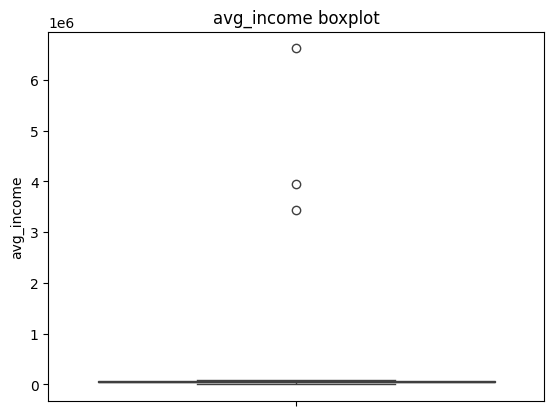

In [27]:
# checking for outliers in avg_income column with boxplot

plt.figure()
sns.boxplot(y=df_1["avg_income"])
plt.title("avg_income boxplot")
plt.show()

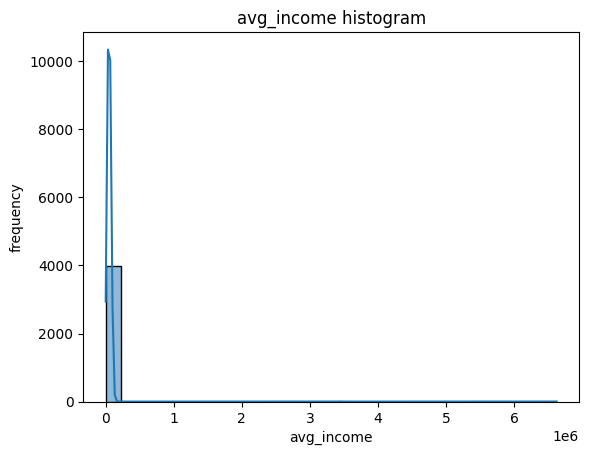

In [28]:
# checking for outliers in avg_income column with histogram

plt.figure()
sns.histplot(df_1["avg_income"], bins = 30, kde = True)
plt.title("avg_income histogram")
plt.xlabel("avg_income")
plt.ylabel("frequency")
plt.show()

In [29]:
df_1["avg_income"].max()

np.int64(6620229)

In [30]:
df_1["avg_income"].min()

np.int64(2204)

In [31]:
df_1.nlargest(10, "avg_income")

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null
310,ATQCUS3729,51,Bengaluru,Salaried IT Employees,Male,Single,6620229,False
1843,ATQCUS0382,33,Delhi NCR,Salaried Other Employees,Male,Married,3943269,False
3047,ATQCUS0866,31,Hyderabad,Freelancers,Male,Married,3429261,False
3094,ATQCUS2990,50,Mumbai,Business Owners,Female,Married,86600,False
1982,ATQCUS1982,53,Hyderabad,Business Owners,Male,Married,86327,False
1406,ATQCUS1985,53,Hyderabad,Business Owners,Male,Married,85593,False
3841,ATQCUS1694,56,Mumbai,Business Owners,Male,Married,85416,False
935,ATQCUS1710,55,Mumbai,Business Owners,Female,Married,84883,False
212,ATQCUS1861,46,Bengaluru,Business Owners,Male,Unknown,84414,False
2737,ATQCUS3034,60,Delhi NCR,Business Owners,Female,Married,84105,False


In [32]:
df_1.nsmallest(10, "avg_income")

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null
246,ATQCUS1915,54,Chennai,Salaried IT Employees,Male,Unknown,2204,False
111,ATQCUS2910,35,Hyderabad,Salaried IT Employees,Female,Married,2986,False
120,ATQCUS3392,21,Chennai,Freelancers,Male,Single,24816,False
73,ATQCUS3345,23,Bengaluru,Freelancers,Male,Single,24888,False
1124,ATQCUS0102,23,Chennai,Freelancers,Male,Married,25159,False
1330,ATQCUS3224,24,Mumbai,Freelancers,Male,Single,25289,False
1050,ATQCUS3437,21,Hyderabad,Freelancers,Male,Single,25297,False
762,ATQCUS0082,21,Bengaluru,Freelancers,Male,Unknown,25301,False
3317,ATQCUS3797,22,Mumbai,Freelancers,Female,Single,25332,False
2946,ATQCUS3439,22,Hyderabad,Freelancers,Male,Single,25473,False


* **There are both high end and low end outliers present in the dataset. However, the boxplot fails to show the low end outliers because our data distribution is highly right-skewed so the low end outliers actually become negative.**
* **Observing the outliers it is clear that they are a result of error while recording data.**
* **Instead of removing the outliers it will be better to impute the values with occupation grouped median avgerage income values. Since the number of  outliers are not very large as compared to the dataset so it will not skew the data analysis outcomes.**
* **Also, a new column will be created to flag the outlier records.**

In [33]:
# Defining avg_income limits and creating a copy of the dataset

Q1 = df_1["avg_income"].quantile(0.25)
Q3 = df_1["avg_income"].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = 10000   # business logic  and dataset values comparison 

df_1_copy = df_1[
    (df_1["avg_income"] >= lower) & (df_1["avg_income"] <= upper)
    ]

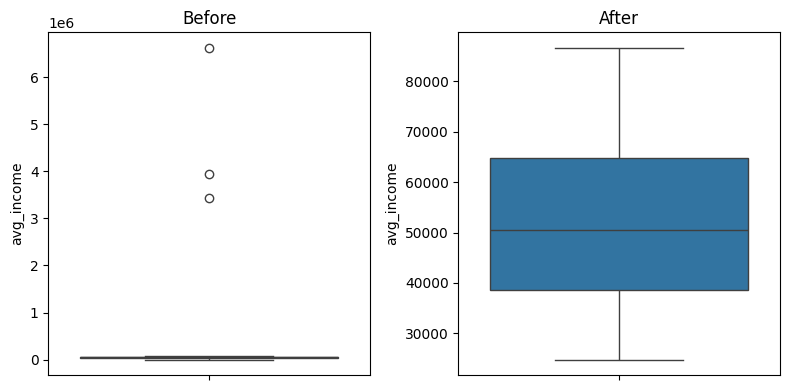

In [34]:
# before/after boxplot comparison

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.boxplot(y=df_1["avg_income"])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(y=df_1_copy["avg_income"])
plt.title("After")

plt.tight_layout()
plt.show()

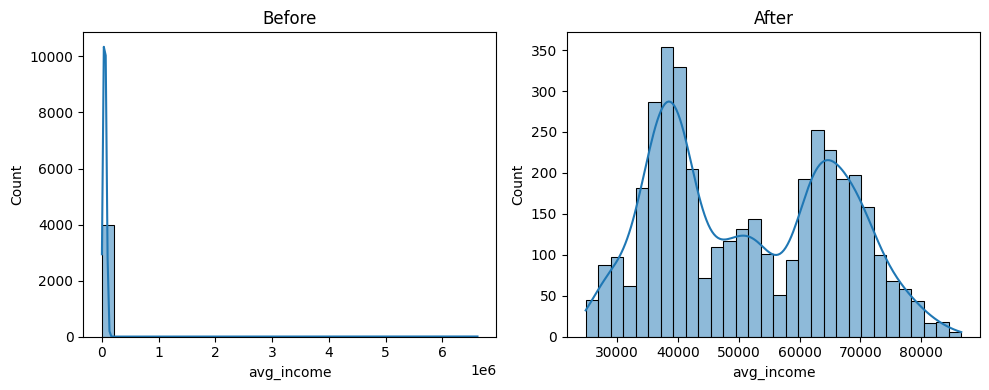

In [35]:
# before/after histogram comparison

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_1["avg_income"], bins=30, kde=True)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(df_1_copy["avg_income"], bins=30, kde=True)
plt.title("After")

plt.tight_layout()
plt.show()

In [36]:
# flagging outlier values before imputing them

df_1["avg_income_outlier"] = (
    (df_1["avg_income"] < lower) | (df_1["avg_income"] > upper)
)

In [37]:
df_1.nlargest(10, "avg_income")

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null,avg_income_outlier
310,ATQCUS3729,51,Bengaluru,Salaried IT Employees,Male,Single,6620229,False,True
1843,ATQCUS0382,33,Delhi NCR,Salaried Other Employees,Male,Married,3943269,False,True
3047,ATQCUS0866,31,Hyderabad,Freelancers,Male,Married,3429261,False,True
3094,ATQCUS2990,50,Mumbai,Business Owners,Female,Married,86600,False,False
1982,ATQCUS1982,53,Hyderabad,Business Owners,Male,Married,86327,False,False
1406,ATQCUS1985,53,Hyderabad,Business Owners,Male,Married,85593,False,False
3841,ATQCUS1694,56,Mumbai,Business Owners,Male,Married,85416,False,False
935,ATQCUS1710,55,Mumbai,Business Owners,Female,Married,84883,False,False
212,ATQCUS1861,46,Bengaluru,Business Owners,Male,Unknown,84414,False,False
2737,ATQCUS3034,60,Delhi NCR,Business Owners,Female,Married,84105,False,False


In [38]:
df_1.nsmallest(10, "avg_income")

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null,avg_income_outlier
246,ATQCUS1915,54,Chennai,Salaried IT Employees,Male,Unknown,2204,False,True
111,ATQCUS2910,35,Hyderabad,Salaried IT Employees,Female,Married,2986,False,True
120,ATQCUS3392,21,Chennai,Freelancers,Male,Single,24816,False,False
73,ATQCUS3345,23,Bengaluru,Freelancers,Male,Single,24888,False,False
1124,ATQCUS0102,23,Chennai,Freelancers,Male,Married,25159,False,False
1330,ATQCUS3224,24,Mumbai,Freelancers,Male,Single,25289,False,False
1050,ATQCUS3437,21,Hyderabad,Freelancers,Male,Single,25297,False,False
762,ATQCUS0082,21,Bengaluru,Freelancers,Male,Unknown,25301,False,False
3317,ATQCUS3797,22,Mumbai,Freelancers,Female,Single,25332,False,False
2946,ATQCUS3439,22,Hyderabad,Freelancers,Male,Single,25473,False,False


In [39]:
occupation_median = df_1.groupby("occupation")["avg_income"].median()

In [40]:
occupation_median

occupation
Business Owners             71015.0
Freelancers                 35664.0
Government Employees        52916.0
Salaried IT Employees       63111.0
Salaried Other Employees    39781.0
Name: avg_income, dtype: float64

In [41]:
# imputing outlier values with occupation grouped median avg_income

df_1.loc[df_1["avg_income_outlier"], "avg_income"] = (
    df_1.loc[df_1["avg_income_outlier"], "occupation"].map(occupation_median)
)

In [42]:
df_1[df_1["avg_income_outlier"] == True]

,customer_id,age,city,occupation,gender,marital_status,avg_income,avg_income_was_null,avg_income_outlier
111,ATQCUS2910,35,Hyderabad,Salaried IT Employees,Female,Married,63111,False,True
246,ATQCUS1915,54,Chennai,Salaried IT Employees,Male,Unknown,63111,False,True
310,ATQCUS3729,51,Bengaluru,Salaried IT Employees,Male,Single,63111,False,True
1843,ATQCUS0382,33,Delhi NCR,Salaried Other Employees,Male,Married,39781,False,True
3047,ATQCUS0866,31,Hyderabad,Freelancers,Male,Married,35664,False,True


**Successfullly flagged and imputed the outliers**

In [43]:
#last check of info overview of dim_customers

df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          4000 non-null   object
 1   age                  4000 non-null   int64 
 2   city                 4000 non-null   object
 3   occupation           4000 non-null   object
 4   gender               4000 non-null   object
 5   marital_status       4000 non-null   object
 6   avg_income           4000 non-null   int64 
 7   avg_income_was_null  4000 non-null   bool  
 8   avg_income_outlier   4000 non-null   bool  
dtypes: bool(2), int64(2), object(5)
memory usage: 257.8+ KB


In [44]:
# creating age_group column 

age_bins = [0, 24, 34, 45, 100]
age_labels =  ["21-24", "25-34", "35-45", "45+"]

df_1["age_group"] = pd.cut(
    df_1["age"],
    bins = age_bins,
    labels = age_labels,
    right = True
)

In [45]:
# creating income_bracket column

income_bins = [0, 30000, 40000, 50000, 60000, 100000]
income_labels = ["20K-30K", "30K-40K", "40K-50K", "50K-60K", "60K+"]

df_1["income_bracket"] = pd.cut(
    df_1["avg_income"],
    bins = income_bins,
    labels = income_labels,
    right = True
)

In [46]:
# reordering the columns

df_1 = df_1[["customer_id", "age", "age_group", "city", "occupation", "gender", "marital_status", "income_bracket", "avg_income", "avg_income_was_null", "avg_income_outlier"]]

In [47]:
df_1.head(10)

,customer_id,age,age_group,city,occupation,gender,marital_status,income_bracket,avg_income,avg_income_was_null,avg_income_outlier
0,ATQCUS1825,52,45+,Bengaluru,Salaried IT Employees,Male,Married,60K+,73523,False,False
1,ATQCUS0809,28,25-34,Hyderabad,Salaried Other Employees,Male,Married,30K-40K,39922,False,False
2,ATQCUS0663,32,25-34,Chennai,Salaried Other Employees,Male,Married,30K-40K,37702,False,False
3,ATQCUS0452,29,25-34,Delhi NCR,Government Employees,Female,Married,50K-60K,54090,False,False
4,ATQCUS3350,23,21-24,Bengaluru,Freelancers,Male,Single,20K-30K,28376,False,False
5,ATQCUS3256,22,21-24,Delhi NCR,Salaried IT Employees,Male,Unknown,40K-50K,46586,False,False
6,ATQCUS3608,27,25-34,Chennai,Freelancers,Male,Single,30K-40K,34966,False,False
7,ATQCUS0611,31,25-34,Chennai,Salaried IT Employees,Male,Married,50K-60K,59078,False,False
8,ATQCUS3856,23,21-24,Bengaluru,Salaried Other Employees,Female,Single,30K-40K,30424,False,False
9,ATQCUS2640,45,35-45,Delhi NCR,Salaried IT Employees,Female,Unknown,60K+,67450,False,False


**dim_customers table is now cleaned and ready to be imported in database**

## Data Cleaning fact_spends

In [48]:
# overview of the data

df_2.head(10)

,customer_id,month,category,payment_type,spend
0,ATQCUS1371,July,Health & Wellness,Credit Card,1114
1,ATQCUS0368,October,Groceries,Credit Card,1466.00
2,ATQCUS0595,May,Health & Wellness,Credit Card,387
3,ATQCUS0667,October,Electronics,Credit Card,Rs.1137
4,ATQCUS3477,September,Bills,UPI,2102
5,ATQCUS1972,October,Health & Wellness,UPI,243.00
6,ATQCUS2843,June,Entertainment,Credit Card,268
7,ATQCUS2634,August,Apparel,Debit Card,737
8,ATQCUS2165,July,Food,UPI,Rs.506
9,ATQCUS0908,September,Others,UPI,Rs.380


In [49]:
df_2.shape

(864125, 5)

In [50]:
# Checking for duplicates

df_2.duplicated().sum()

np.int64(125)

**There are 125 duplicates in this dataset**

In [51]:
# Removing duplicates

df_2.drop_duplicates(inplace=True)

In [52]:
df_2.shape

(864000, 5)

**Removed the duplicates**

In [53]:
# overview of dataset information

df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864000 entries, 0 to 863999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   customer_id   864000 non-null  object
 1   month         864000 non-null  object
 2   category      863514 non-null  object
 3   payment_type  864000 non-null  object
 4   spend         864000 non-null  object
dtypes: object(5)
memory usage: 39.6+ MB


In [54]:
# Checking the value counts for the categorical columns

categorical_cols = [
    col for col in df_2.select_dtypes(include=["object", "category"]).columns
    if not col.endswith("_id")
]

for col in categorical_cols:
    print(f"\n\nValue counts for {col}:")
    print(df_2[col].value_counts(dropna=False))



Value counts for month:
month
July         144000
October      144000
May          144000
September    144000
June         144000
August       144000
Name: count, dtype: int64


Value counts for category:
category
Travel               95957
Apparel              95955
Others               95949
Groceries            95949
Bills                95949
Health & Wellness    95945
Food                 95940
Entertainment        95937
Electronics          95933
NaN                    486
Name: count, dtype: int64


Value counts for payment_type:
payment_type
Credit Card    216000
UPI            216000
Debit Card     216000
Net Banking    216000
Name: count, dtype: int64


Value counts for spend:
spend
120        956
122        933
123        910
144        909
135        904
          ... 
4905         1
2324.00      1
Rs.4702      1
3157.00      1
4653         1
Name: count, Length: 16891, dtype: int64


* **There are null values in the category column.**
* **There is data irregularity in the spend column like irregular prefix and suffix. Also it has wrong data type.**

In [55]:
# Removing "Rs." prefix and ".00" suffix from avg_income column

df_2["spend"] = (
    df_2["spend"]
        .str.replace("Rs.", "", regex=False)
        .str.replace(".00", "", regex=False)
)

df_2.head(10)

,customer_id,month,category,payment_type,spend
0,ATQCUS1371,July,Health & Wellness,Credit Card,1114
1,ATQCUS0368,October,Groceries,Credit Card,1466
2,ATQCUS0595,May,Health & Wellness,Credit Card,387
3,ATQCUS0667,October,Electronics,Credit Card,1137
4,ATQCUS3477,September,Bills,UPI,2102
5,ATQCUS1972,October,Health & Wellness,UPI,243
6,ATQCUS2843,June,Entertainment,Credit Card,268
7,ATQCUS2634,August,Apparel,Debit Card,737
8,ATQCUS2165,July,Food,UPI,506
9,ATQCUS0908,September,Others,UPI,380


In [56]:
# changing spend datatype to int

df_2["spend"] = df_2["spend"].astype(int)

In [57]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864000 entries, 0 to 863999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   customer_id   864000 non-null  object
 1   month         864000 non-null  object
 2   category      863514 non-null  object
 3   payment_type  864000 non-null  object
 4   spend         864000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 39.6+ MB


**Cleaned and Standardized the spend column and changed its datatype to int.**

In [58]:
# filling null values in category column as Unknown 

df_2["category"] = df_2["category"].fillna("Unknown")
df_2["category"].isnull().sum()

np.int64(0)

In [59]:
df_2["category"].value_counts()

category
Travel               95957
Apparel              95955
Others               95949
Groceries            95949
Bills                95949
Health & Wellness    95945
Food                 95940
Entertainment        95937
Electronics          95933
Unknown                486
Name: count, dtype: int64

**Handled the null values in spend column**

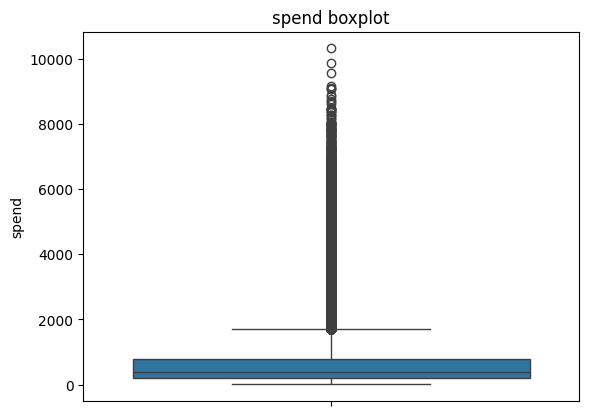

In [60]:
# checking for outliers in avg_income column with boxplot

plt.figure()
sns.boxplot(y=df_2["spend"])
plt.title("spend boxplot")
plt.show()

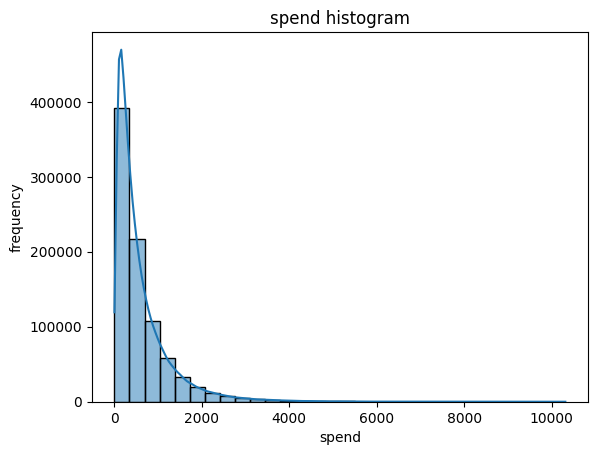

In [61]:
# checking for outliers in avg_income column with histogram

plt.figure()
sns.histplot(df_2["spend"], bins = 30, kde = True)
plt.title("spend histogram")
plt.xlabel("spend")
plt.ylabel("frequency")
plt.show()

In [62]:
df_2["spend"].max()

np.int64(10313)

In [63]:
df_2["spend"].min()

np.int64(6)

In [64]:
df_2.nlargest(10, "spend")

,customer_id,month,category,payment_type,spend
214800,ATQCUS0903,September,Bills,Credit Card,10313
28680,ATQCUS0150,September,Bills,Credit Card,9867
615425,ATQCUS0907,September,Bills,Credit Card,9546
629277,ATQCUS0135,September,Bills,Credit Card,9161
276609,ATQCUS0170,September,Bills,Credit Card,9088
111429,ATQCUS0345,September,Bills,Credit Card,9065
341191,ATQCUS2547,September,Health & Wellness,Credit Card,9055
817143,ATQCUS0354,August,Bills,Credit Card,8878
281019,ATQCUS0144,September,Bills,Credit Card,8856
627151,ATQCUS0159,September,Bills,Credit Card,8763


In [65]:
df_2.nsmallest(10, "spend")

,customer_id,month,category,payment_type,spend
285145,ATQCUS2067,June,Bills,Net Banking,6
516611,ATQCUS0643,June,Others,Net Banking,6
829694,ATQCUS3610,May,Others,Net Banking,6
431148,ATQCUS0742,May,Others,Net Banking,7
450677,ATQCUS3882,May,Others,Net Banking,7
687146,ATQCUS3378,May,Others,Net Banking,7
56523,ATQCUS2067,May,Bills,Net Banking,8
393011,ATQCUS3912,May,Others,Net Banking,8
786184,ATQCUS2066,June,Others,Net Banking,8
308745,ATQCUS3904,May,Bills,Net Banking,9


**Although dataset has both high end and low end outliers as shown by the boxplot and histogram, but by careful overview both of these outliers are not data errors rather they are real world transactions. So, there is no need to remove them as removing them will affect our analysis and findings.**

In [66]:
#last check of info overview of fact_spends

df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864000 entries, 0 to 863999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   customer_id   864000 non-null  object
 1   month         864000 non-null  object
 2   category      864000 non-null  object
 3   payment_type  864000 non-null  object
 4   spend         864000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 39.6+ MB


**fact_spends table is now cleaned and ready to be imported in database**

### Saving clean Datasets as csv

In [69]:
#dim_customers
df_1.to_csv("dim_customers_clean.csv", index = False)

#fact_spends
df_2.to_csv("fact_spends_clean.csv", index = False)

**Cleaned datasets saved as csv**

### Loading the datasets into the Database

In [68]:
from sqlalchemy import create_engine

# connecting to Postgresql

username = "postgres"
password = "SQL1234"
host = "localhost"
port = "5433"
database = "bank_db"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# loading the Dataframes

dfs = {
    "dim_customers": df_1,
    "fact_spends": df_2
}

for table_name, df in dfs.items():
    df.to_sql(
        table_name,
        engine,
        if_exists="replace",
        index=False
    )
    print(f"{table_name} loaded in database {database}")

dim_customers loaded in database bank_db
fact_spends loaded in database bank_db


**Data Successfullly loaded in database**